In [1]:
import numpy as np
from scipy.optimize import minimize
from scipy.interpolate import CubicSpline
from scipy.sparse import diags
from scipy.sparse.linalg import eigsh
import matplotlib.pyplot as plt
from typing import Optional
from scipy.optimize import differential_evolution
import time

In [2]:
# ----------------------------
# Constants (SI)
# ----------------------------

h = 6.62607015e-34
hbar = h / (2.0 * np.pi)
e = 1.602176634e-19
Phi0 = h / (2.0 * e)

# ----------------------------
# Nonlinear branch energy f(phi, phi_e) and analytic derivatives
# phi is dimensionless phase; phi_e is external flux through both loops in total in units of Phi0 (dimensionless)
# ----------------------------
def f(phi, phi_e, EL, EJ):
    return 0.5 * EL * phi**2 - 2.0 * EJ * np.cos(np.pi * phi_e) * np.cos(phi)

def df(phi, phi_e, EL, EJ):
    return EL * phi + 2.0 * EJ * np.cos(np.pi * phi_e) * np.sin(phi)

def d2f(phi, phi_e, EL, EJ):
    return EL + 2.0 * EJ * np.cos(np.pi * phi_e) * np.cos(phi)

# ----------------------------
# Full constrained potential:
# phi_total = phi1 + phi2 + ... + phiN, eliminate phi1 = phi_total - sum(phi_extra)
# x = phi_extra = [phi2, phi3, ..., phiN] has length N-1
# phi_e_array has length N is the external flux for each branch
# ----------------------------
def U_full(phi_total, x, phi_e_array, EL, EJ):
    phi1 = phi_total - np.sum(x)
    U = f(phi1, phi_e_array[0], EL, EJ)
    for i in range(x.size):
        U += f(x[i], phi_e_array[i + 1], EL, EJ)
    return U

def grad_U_full(phi_total, x, phi_e_array, EL, EJ):
    phi1 = phi_total - np.sum(x)
    df_phi1 = df(phi1, phi_e_array[0], EL, EJ)
    g = np.empty_like(x, dtype=float)
    for i in range(x.size):
        g[i] = -df_phi1 + df(x[i], phi_e_array[i + 1], EL, EJ)
    return g

def hess_U_full(phi_total, x, phi_e_array, EL, EJ):
    phi1 = phi_total - np.sum(x)
    a = d2f(phi1, phi_e_array[0], EL, EJ)  # all off-diagonal entries are a
    n = x.size
    H = np.full((n, n), a, dtype=float)
    for i in range(n):
        H[i, i] = a + d2f(x[i], phi_e_array[i + 1], EL, EJ)
    return H

# ----------------------------
# Minimization domain / periodicity for phase-like variables
# ----------------------------
phi_period = 2.0 * np.pi
phi_min_domain = -0.5 * phi_period
phi_max_domain =  0.5 * phi_period

# n_starts is the number of random restarts for global optimization; seed is for reproducibility
# phi_total is the coordinate we want to keep; x are the extra coordinates we minimize out
# phi_e_array is the external flux for each branch (length N_potential), this is fixed for the whole optimization
def minimize_phi_extra(phi_total, phi_e_array, x0, N_potential, EL, EJ, n_starts, seed, options = None):
    rng = np.random.default_rng(seed)
    n_extra = N_potential - 1

    # objective / derivatives for scipy
    def obj(x):
        return float(U_full(phi_total, x, phi_e_array, EL, EJ))

    def jac(x):
        return grad_U_full(phi_total, x, phi_e_array, EL, EJ)

    def hess(x):
        return hess_U_full(phi_total, x, phi_e_array, EL, EJ)

    best_x = None
    best_fun = np.inf

    # random-restart global search: sample x0 uniformly, run local minimizer, keep best
    for i in range(n_starts):
        if i == 0 and x0 is not None:
            x0 = np.array(x0, dtype=float)
        else:
            x0 = rng.uniform(phi_min_domain, phi_max_domain, size=n_extra)

        res = minimize(
            obj,
            x0,
            method="trust-exact",      # uses analytic jac + hess
            jac=jac,
            hess=hess,
            options=options,
        )

        if res.fun < best_fun:
            best_fun = float(res.fun)
            best_x = np.array(res.x, dtype=float)
    
    best_x = np.mod(best_x - phi_min_domain, phi_period) + phi_min_domain

    return best_x, best_fun

# ----------------------------
# Compute the effective 1D potential U_eff(phi_total) by minimizing out internal degrees of freedom
# 
# This performs a "Born-Oppenheimer" approximation: at each value of the total flux phi_total,
# we minimize over the internal flux distributions [phi2, phi3, ..., phiN] to find the 
# ground-state energy. This reduces the N-dimensional problem to an effective 1D problem.
#
# The result U_eff(phi_total) is the potential energy surface that the system sees when 
# the internal coordinates have relaxed to their optimal configuration.
# ----------------------------

# phi_grid is the array of total flux values we want to evaluate U_eff at
# phi_e_array is the external flux for each branch (length N_potential), this is fixed
# N_potential is the total number of branches (including phi1), EL and EJ are the energy scales
def compute_Ueff(phi_grid, phi_e_array, N_potential, EL, EJ, n_starts, seed, options=None):
    # Pre-allocate arrays to store results at each grid point
    Ueff = np.empty_like(phi_grid, dtype=float)                      # effective 1D potential energy
    x_star = np.empty((phi_grid.size, N_potential - 1), dtype=float) # optimal internal coordinates. Row i is the optimal [phi2, phi3, ..., phiN] for phi_total = phi_grid[i]
    
    # Warm-start optimization: use previous point's solution as initial guess for next point
    # This helps the optimizer follow the same energy minimum branch smoothly along phi_total
    x_prev = None
    
    for i, phi_total in enumerate(phi_grid):
        # Minimize U_full over internal coordinates x = [phi2, ..., phiN] at fixed phi_total
        x_opt, U_opt = minimize_phi_extra(phi_total, phi_e_array, x_prev, N_potential, EL, EJ, n_starts, seed, options=options)
        
        # Store the minimized energy and optimal internal coordinates
        x_star[i, :] = x_opt   # optimal flux distribution at this phi_total
        Ueff[i] = U_opt        # minimum energy = effective potential
        
        # Use this solution to initialize the next optimization step (warm start)
        x_prev = x_opt
    
    return Ueff, x_star

# ----------------------------
# Diagonalize the 1D quantum Hamiltonian H = 4*EC*n^2 + U_eff(phi) using finite differences
#
# The number operator n = -i*d/dphi becomes a discretized derivative, so the kinetic energy
# 4*EC*n^2 = -4*EC*d²/dphi² is represented by a finite-difference Laplacian matrix.
#
# We impose Dirichlet (zero) boundary conditions: ψ(phi_min) = ψ(phi_max) = 0
# This is appropriate when U_eff → ∞ at the boundaries, confining the wavefunction.
#
# order=3: Standard 3-point stencil (2nd-order accurate), gives tridiagonal matrix
# order=5: Higher-accuracy 5-point stencil (4th-order accurate), gives pentadiagonal matrix
# ----------------------------
def diagonalize_fd(phi_grid, Ueff, EC, n_levels, order):
    dphi = phi_grid[1] - phi_grid[0]  # uniform grid spacing
    
    # Enforce Dirichlet (zero) boundary conditions by excluding boundary points
    # We only solve for the wavefunction at interior points: phi_grid[1:-1]
    U_in = Ueff[1:-1]  # potential on interior points, excludes the two boundaries where ψ=0
    N = U_in.size      # number of interior points
    
    # KE and U_in properly account for the potential = 0 at boundaries
    if order == 3: 
        # Standard 3-point centered difference: ψ'' ≈ (ψ_{i-1} - 2ψ_i + ψ_{i+1})/dphi²
        # Kinetic energy: -4*EC*d²/dphi² → diagonal: +8*EC/dphi², off-diag: -4*EC/dphi²
        main = (8.0 * EC / dphi**2) + U_in      # diagonal: kinetic + potential
        off1 = (-4.0 * EC / dphi**2) * np.ones(N - 1)  # nearest-neighbor coupling due to kinetic energy
        H = diags([off1, main, off1], offsets=[-1, 0, 1], format="csc")
    
    elif order == 5:
        # 5-point stencil for higher accuracy (4th-order in interior):
        # ψ'' ≈ (-ψ_{i+2} + 16ψ_{i+1} - 30ψ_i + 16ψ_{i-1} - ψ_{i-2}) / (12*dphi²)
        # Multiply by -4*EC to get kinetic energy operator coefficients
        c0 = (10.0 * EC / dphi**2)             # diagonal (note: 30/12 * 4 = 10)
        c1 = (-16.0 * EC / (3.0 * dphi**2))    # ±1 neighbors (16/12 * 4 = 16/3)
        c2 = (1.0 * EC / (3.0 * dphi**2))      # ±2 neighbors (1/12 * 4 = 1/3)
        
        main = c0 + U_in                       # diagonal: kinetic + potential
        off1 = c1 * np.ones(N - 1)            # nearest neighbors
        off2 = c2 * np.ones(N - 2)            # next-nearest neighbors
        H = diags([off2, off1, main, off1, off2], offsets=[-2, -1, 0, 1, 2], format="csc")
    
    else:
        raise ValueError("order must be 3 or 5")
    
    # Find the lowest n_levels eigenstates using sparse eigenvalue solver
    # "SA" = smallest algebraic eigenvalues (ground state and low-lying excited states)
    evals, evecs = eigsh(H, k=n_levels, which="SA")
    
    # Sort eigenvalues in ascending order (should already be sorted, but ensure it)
    idx = np.argsort(evals)
    
    return evals[idx], evecs[:, idx]

def full_analysis(phi_total_mag, N_opt, N_fine, phi_e_array, N_potential, EL, EJ, EC, n_levels, order: Optional[int] = 5, n_starts: Optional[int] = 3, seed: Optional[int] = 0, options: Optional[dict] = {"maxiter": 200, "gtol": 1e-8}):

    # coarse grid for minimizing out extra coordinates (expensive)
    phi_total_min = -phi_total_mag * 2 * np.pi
    phi_total_max =  phi_total_mag * 2 * np.pi
    phi_opt = np.linspace(phi_total_min, phi_total_max, N_opt)

    Ueff_opt, x_star = compute_Ueff(phi_opt, phi_e_array, N_potential, EL, EJ, n_starts, seed, options=options)

    # spline onto a finer grid for diagonalization (cheap)
    phi_fine = np.linspace(phi_total_min, phi_total_max, N_fine)
    U_spline = CubicSpline(phi_opt, Ueff_opt, bc_type="natural")
    Ueff_fine = U_spline(phi_fine)

    # diagonalize with non-periodic boundaries
    E_GHz, V = diagonalize_fd(phi_fine, Ueff_fine, EC, n_levels, order)

    return {'phi_fine' : phi_fine, 'Ueff_fine' : Ueff_fine, 'phi_opt' : phi_opt, 'Ueff_opt': Ueff_opt, 'E_GHz' : E_GHz, 'V' : V, 'N_opt' : N_opt, 'N_fine' : N_fine, 'phi_total_min' : phi_total_min, 'phi_total_max' : phi_total_max, 'x_star' : x_star}
    
# classical frequency calculation, equal flux through each linc loop:
# phi_e_array is the array of external fluxes for each branch (size N_potential)
def classical_freq(phi_e_array, EC, EL, EJ):
    k_array = EL + 2 * EJ * np.cos(np.pi * phi_e_array)
    k_eff = np.sum(1.0 / k_array) ** (-1)  # effective spring constant for total flux mode
    freq = np.sqrt(8 * EC * k_eff)  # classical frequency in GHz
    return freq  

# classical frequency as a function of applied flux, for the case where we apply the same flux to all branches 
def classical_freq_function_of_flux(phi_e_initial, phi_e_apply, EC, EL, EJ):
    phi_e_initial = np.array(phi_e_initial, dtype=float) # make sure array
    freq_array = np.zeros_like(phi_e_apply, dtype=float)
    for i, phi_e in enumerate(phi_e_apply):
        freq_array[i] = classical_freq(phi_e_initial + phi_e, EC, EL, EJ)
    return freq_array

# Single Flux Point

In [65]:
# ----------------------------
# Circuit parameters
# ----------------------------
# C = 60e-15
# L = 10e-9

# EJ = 12.0 # in GHz
# EL = ((hbar / (2.0 * e)) ** 2 / L) / (h * 1e9)  # convert to GHz
# EC = (e**2 / (2.0 * C))/(h * 1e9)  # convert to GHz

N_potential = 3  # total number of branches in U = sum_i f(phi_i, phi_ei)

freq = 6.5 # in GHz, at kerr free point
EL_EJ_ratio = 3.333

EC = 0.1
EL_eff_target = freq**2 / (8*EC)     # what the *effective* quadratic coefficient should be
EL = N_potential * EL_eff_target     # branch EL so that EL_eff = EL/N_potential = EL_eff_target
EJ = EL / EL_EJ_ratio

result = full_analysis(
    phi_total_mag=2, 
    N_opt=15, 
    N_fine=400, 
    phi_e_array=np.array([0.2, 0.5, 0.2], dtype=float), 
    N_potential=N_potential, 
    EL=EL, 
    EJ=EJ, 
    EC=EC, 
    n_levels=3, 
    order=5, 
    n_starts=1, 
    seed=0,
    options={"maxiter": 100, "gtol": 1e-7}
)

E_GHz = result['E_GHz']

print("Lowest energy levels (GHz):")
for i, Ei in enumerate(E_GHz):
    print(f"  E[{i}] = {Ei:.9f} GHz")

print("\nTransition frequencies (GHz):")
for i in range(1, len(E_GHz)):
    print(f"  f_{i}{i-1} = {E_GHz[i] - E_GHz[i-1]:.9f} GHz")

print("\nAnharmonicity (GHz):")
print(f"  α = {E_GHz[2] - 2*E_GHz[1] + E_GHz[0]:.9f} GHz")

print(result['x_star'])
print(result['phi_opt'])


Lowest energy levels (GHz):
  E[0] = -150.150325323 GHz
  E[1] = -142.795105725 GHz
  E[2] = -135.445893594 GHz

Transition frequencies (GHz):
  f_10 = 7.355219598 GHz
  f_21 = 7.349212131 GHz

Anharmonicity (GHz):
  α = -0.006007468 GHz
[[ 2.39579204e+00  1.94369663e+00]
 [ 2.85660012e+00  2.61089050e+00]
 [-3.04939240e+00 -2.96329331e+00]
 [-2.64135252e+00 -2.26971534e+00]
 [-2.11819495e+00 -1.63369623e+00]
 [-1.47848317e+00 -1.05595421e+00]
 [-7.58714145e-01 -5.18240832e-01]
 [ 2.62101452e-12  2.55129251e-12]
 [ 7.58714142e-01  5.18240830e-01]
 [ 1.47848317e+00  1.05595422e+00]
 [ 2.11819495e+00  1.63369623e+00]
 [ 2.64135254e+00  2.26971531e+00]
 [ 3.04939242e+00  2.96329325e+00]
 [-2.85660012e+00 -2.61089050e+00]
 [-2.39579205e+00 -1.94369664e+00]]
[-12.56637061 -10.77117481  -8.97597901  -7.18078321  -5.38558741
  -3.5903916   -1.7951958    0.           1.7951958    3.5903916
   5.38558741   7.18078321   8.97597901  10.77117481  12.56637061]


# Plot Potential and Wave functions

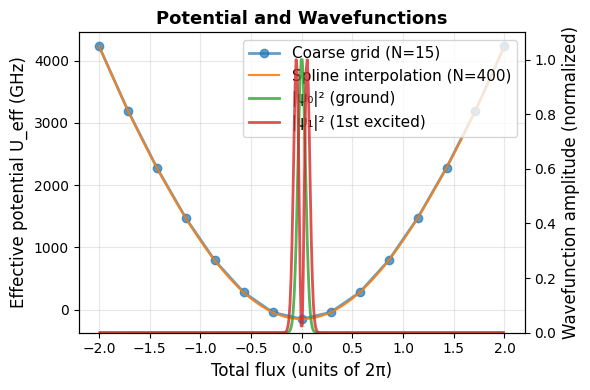

In [66]:
phi_opt = result['phi_opt']
Ueff_opt = result['Ueff_opt']
N_opt = result['N_opt']
phi_fine = result['phi_fine']
Ueff_fine = result['Ueff_fine']
N_fine = result['N_fine']
V = result['V']

# Plot the raw coarse data and the fine spline interpolation with wavefunctions
fig, ax = plt.subplots(figsize=(6, 4))

# Plot raw coarse grid data
ax.plot(phi_opt / (2*np.pi), Ueff_opt, 'o-', linewidth=2, markersize=6, 
        label=f'Coarse grid (N={N_opt})', color='C0', alpha=0.7)

# Plot fine spline interpolation
ax.plot(phi_fine / (2*np.pi), Ueff_fine, '-', linewidth=1.5, 
        label=f'Spline interpolation (N={N_fine})', color='C1', alpha=0.9)

ax.set_xlabel('Total flux (units of 2π)', fontsize=12)
ax.set_ylabel('Effective potential U_eff (GHz)', fontsize=12)
ax.set_title('Potential and Wavefunctions', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

# Create second y-axis for wavefunctions
ax2 = ax.twinx()

# Interior grid points where wavefunctions are defined (exclude boundaries)
phi_interior = phi_fine[1:-1]

# Plot ground state wavefunction (|ψ₀|²)
psi0_sq = V[:, 0]**2
psi0_sq_normalized = psi0_sq / np.max(psi0_sq)  # normalize for visualization
ax2.plot(phi_interior / (2*np.pi), psi0_sq_normalized, '-', linewidth=2, 
         label='|ψ₀|² (ground)', color='C2', alpha=0.8)

# Plot first excited state wavefunction (|ψ₁|²)
psi1_sq = V[:, 1]**2
psi1_sq_normalized = psi1_sq / np.max(psi1_sq)  # normalize for visualization
ax2.plot(phi_interior / (2*np.pi), psi1_sq_normalized, '-', linewidth=2, 
         label='|ψ₁|² (1st excited)', color='C3', alpha=0.8)

ax2.set_ylabel('Wavefunction amplitude (normalized)', fontsize=12)
ax2.set_ylim(0, 1.1)

# Combine legends from both axes
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=11, loc='upper right')

plt.tight_layout()
plt.show()

In [16]:
print(f"\nCharging energy EC = {EC:.3f} GHz")
print(f"Inductive energy EL = {EL:.3f} GHz")
print(f"Josephson energy EJ = {EJ:.3f} GHz")


Charging energy EC = 0.100 GHz
Inductive energy EL = 158.438 GHz
Josephson energy EJ = 47.536 GHz


# Frequency vs Flux

/var/folders/h4/tktr_62d465dx1dq_x0czdz80000gn/T/ipykernel_32704/3754662665.py:217: RuntimeWarning: invalid value encountered in sqrt
  freq = np.sqrt(8 * EC * k_eff)  # classical frequency in GHz


Running flux sweep...
  Completed 10/40 flux points
  Completed 20/40 flux points
  Completed 30/40 flux points
  Completed 40/40 flux points
Flux sweep completed!



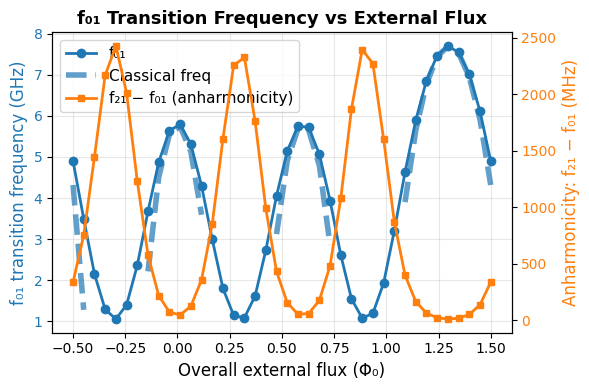

In [8]:
# ----------------------------
# Flux sweep: overall external flux + different initial offsets per loop
# ----------------------------

N_potential = 3  # total number of branches in U = sum_i f(phi_i, phi_ei)

freq = 6.5 # in GHz, at kerr free point
EL_EJ_ratio = 1.8

EC = 0.13
EL_eff_target = freq**2 / (8*EC)     # what the *effective* quadratic coefficient should be
EL = N_potential * EL_eff_target     # branch EL so that EL_eff = EL/N_potential = EL_eff_target

EL = 200
EJ = EL / EL_EJ_ratio

# Define different initial flux offsets for each loop (in units of Phi0)
phi_e_initial = np.array( [-0.7, 0.1, 0.7] , dtype=float) # -0.7, +0.1, +0.7 
# Sweep range for overall external flux
phi_ext_sweep = np.linspace(-0.5, 1.5, 40)  # sweep flux in units of Phi0

n_levels_sweep = 3  # number of energy levels to compute at each flux point
N_fine = 1000
E_sweep = np.zeros((len(phi_ext_sweep), n_levels_sweep))
Ueff_fine_sweep_all = np.zeros((len(phi_ext_sweep), N_fine))  # store all potentials

E_sweep_classical = classical_freq_function_of_flux(phi_e_initial, phi_ext_sweep, EC, EL, EJ)  # compute classical frequencies for the whole sweep

print("Running flux sweep...")
for i, phi_ext in enumerate(phi_ext_sweep):
    # Set external flux for each branch: initial offset + overall flux
    phi_e_array_sweep = phi_e_initial + phi_ext
    
    # Compute effective potential
    result = full_analysis(
    phi_total_mag=2, 
    N_opt=40, 
    N_fine=N_fine, 
    phi_e_array=phi_e_array_sweep, 
    N_potential=N_potential, 
    EL=EL, 
    EJ=EJ, 
    EC=EC, 
    n_levels=n_levels_sweep, 
    order=5, 
    n_starts=1, 
    seed=0,
    options={"maxiter": 100, "gtol": 1e-9})
    
    Ueff_fine_sweep_all[i, :] = result["Ueff_fine"]  # store for later plotting
    E_sweep[i, :] = result["E_GHz"]  # store energy levels for this flux point

    if (i + 1) % 10 == 0:
        print(f"  Completed {i+1}/{len(phi_ext_sweep)} flux points")

print("Flux sweep completed!\n")


# Plot f_01 transition frequency vs external flux
fig, ax = plt.subplots(figsize=(6, 4))

# Plot f_01 (ground to first excited) on left axis
f01 = E_sweep[:, 1] - E_sweep[:, 0]
ax.plot(phi_ext_sweep, f01, '-o', linewidth=2, markersize=6, color='C0', label='f₀₁')
ax.plot(phi_ext_sweep, E_sweep_classical, '--', linewidth=4, color='C0', alpha=0.7, label='Classical freq')

ax.set_xlabel('Overall external flux (Φ₀)', fontsize=12)
ax.set_ylabel('f₀₁ transition frequency (GHz)', fontsize=12, color='C0')
ax.tick_params(axis='y', labelcolor='C0')
ax.set_title('f₀₁ Transition Frequency vs External Flux', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

# Create second y-axis for anharmonicity
ax2 = ax.twinx()

# Plot anharmonicity (f_21 - f_01) on right axis
f21 = E_sweep[:, 2] - E_sweep[:, 1]
anharmonicity = f21 - f01
ax2.plot(phi_ext_sweep, anharmonicity * 1e3, '-s', linewidth=2, markersize=5, color='C1', label='f₂₁ − f₀₁ (anharmonicity)')

ax2.set_ylabel('Anharmonicity: f₂₁ − f₀₁ (MHz)', fontsize=12, color='C1')
ax2.tick_params(axis='y', labelcolor='C1')

# Combine legends
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=11, loc='upper left')

plt.tight_layout()
plt.show()

# Data L1

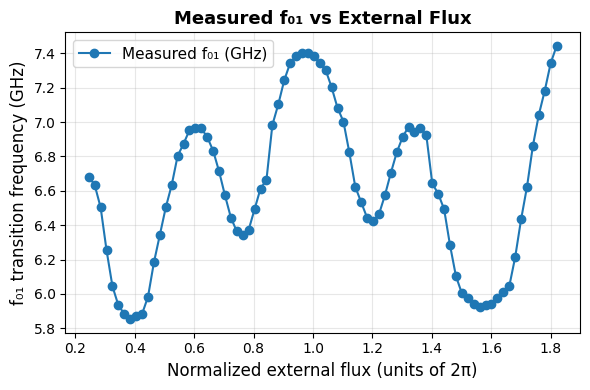

80 80


In [5]:
# =====================================================================
# Experimental data
# =====================================================================

flux_npi = -3.2     # raw flux value corresponding to -pi
flux_pi  = 2.65     # raw flux value corresponding to +pi
period   = flux_pi - flux_npi  # one full period in raw units

# Raw DC flux points (coil units)
DC_x = np.array([-2.4833, -2.425, -2.3667, -2.3083, -2.25, -2.1917, -2.1333,
        -2.0750, -2.0167, -1.9583, -1.90, -1.8417, -1.7833, -1.725,
        -1.6667, -1.6083, -1.55, -1.4917, -1.4333, -1.375, -1.3167,
         -1.2583, -1.2, -1.1417, -1.0833, -1.025, -0.9667, -0.9083,
        -0.85, -0.7917, -0.7333, -0.675, -0.6167, -0.5583, -0.5,
        -0.4417, -0.3833, -0.325, -0.2667, -0.2083, -0.15, -0.0917,
        -0.0333, 0.025, 0.0833, 0.1417, 0.2, 0.2583, 0.3167, 0.375,
        0.4333, 0.4917, 0.55, 0.6083, 0.6667, 0.725, 0.7833, 0.8417,
        0.9, 0.9583, 1.0167, 1.075, 1.1333, 1.1917, 1.25, 1.3083,
        1.3667, 1.425, 1.4833, 1.5417, 1.6, 1.6583, 1.7167, 1.775,
        1.8333, 1.8917, 1.95, 2.0083, 2.0667, 2.125])

# Normalize: map one period → 2 (same periodicity as cos(π φ_e) in simulation)
DC_x = (DC_x - flux_npi) / period * 2

# Measured coupler frequency (Hz); some are half-frequency × 2
peak_point = np.array([2.3e9, 2.25e9, 2.12e9, 1.87e9, 1.66e9, 1.55e9, 1.5e9,
              1.47e9, 1.49e9, 1.50e9, 1.60e9, 1.8e9, 1.96e9, 2.12e9,
              2.25e9, 2.42e9, 2.49e9, 2.57e9, 2.58e9, 2.58e9, 2.53e9,
              2.45e9, 2.33e9, 2.19e9, 2.06e9, 1.98e9, 1.96e9, 1.99e9,
              2.11e9, 2.23e9, 2.28e9, 1.3e9*2, 1.36e9*2, 1.43e9*2, 1.48e9*2,
              1.5e9*2, 1.51e9*2, 1.51e9*2, 1.50e9*2, 1.48e9*2, 1.46e9*2, 1.41e9*2,
              1.35e9*2, 2.62e9, 2.44e9, 2.24e9, 2.15e9, 2.06e9, 2.04e9, 2.08e9,
              2.19e9, 2.32e9, 2.44e9, 2.53e9, 2.59e9, 1.28e9*2, 2.58e9, 2.54e9,
              2.26e9, 2.2e9, 2.11e9, 1.9e9, 1.72e9, 1.62e9, 1.59e9, 1.56e9,
              1.54e9, 1.55e9, 1.56e9, 1.59e9, 1.63e9, 1.66e9, 1.83e9, 2.05e9,
              2.24e9, 2.48e9, 1.33e9*2, 1.4e9*2, 1.48e9*2, 1.53e9*2]) + 4383.375200045928e6

# Convert to GHz (same units as simulation output)
f01_data_GHz = peak_point / 1e9

plt.figure(figsize=(6, 4))
plt.plot(DC_x, f01_data_GHz, 'o-', label='Measured f₀₁ (GHz)', color='C0')
plt.xlabel('Normalized external flux (units of 2π)', fontsize=12)
plt.ylabel('f₀₁ transition frequency (GHz)', fontsize=12)
plt.title('Measured f₀₁ vs External Flux', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(len(DC_x), len(f01_data_GHz))

# Fit data L1

In [7]:

flux_npi = -3.2     # raw flux value corresponding to -pi
flux_pi  = 2.65     # raw flux value corresponding to +pi
period   = flux_pi - flux_npi  # one full period in raw units

# Raw DC flux points (coil units)
DC_x = np.array([-2.4833, -2.425, -2.3667, -2.3083, -2.25, -2.1917, -2.1333,
        -2.0750, -2.0167, -1.9583, -1.90, -1.8417, -1.7833, -1.725,
        -1.6667, -1.6083, -1.55, -1.4917, -1.4333, -1.375, -1.3167,
         -1.2583, -1.2, -1.1417, -1.0833, -1.025, -0.9667, -0.9083,
        -0.85, -0.7917, -0.7333, -0.675, -0.6167, -0.5583, -0.5,
        -0.4417, -0.3833, -0.325, -0.2667, -0.2083, -0.15, -0.0917,
        -0.0333, 0.025, 0.0833, 0.1417, 0.2, 0.2583, 0.3167, 0.375,
        0.4333, 0.4917, 0.55, 0.6083, 0.6667, 0.725, 0.7833, 0.8417,
        0.9, 0.9583, 1.0167, 1.075, 1.1333, 1.1917, 1.25, 1.3083,
        1.3667, 1.425, 1.4833, 1.5417, 1.6, 1.6583, 1.7167, 1.775,
        1.8333, 1.8917, 1.95, 2.0083, 2.0667, 2.125])

# Normalize: map one period → 2 (same periodicity as cos(π φ_e) in simulation)
DC_x = (DC_x - flux_npi) / period * 2

# Measured coupler frequency (Hz); some are half-frequency × 2
peak_point = np.array([2.3e9, 2.25e9, 2.12e9, 1.87e9, 1.66e9, 1.55e9, 1.5e9,
              1.47e9, 1.49e9, 1.50e9, 1.60e9, 1.8e9, 1.96e9, 2.12e9,
              2.25e9, 2.42e9, 2.49e9, 2.57e9, 2.58e9, 2.58e9, 2.53e9,
              2.45e9, 2.33e9, 2.19e9, 2.06e9, 1.98e9, 1.96e9, 1.99e9,
              2.11e9, 2.23e9, 2.28e9, 1.3e9*2, 1.36e9*2, 1.43e9*2, 1.48e9*2,
              1.5e9*2, 1.51e9*2, 1.51e9*2, 1.50e9*2, 1.48e9*2, 1.46e9*2, 1.41e9*2,
              1.35e9*2, 2.62e9, 2.44e9, 2.24e9, 2.15e9, 2.06e9, 2.04e9, 2.08e9,
              2.19e9, 2.32e9, 2.44e9, 2.53e9, 2.59e9, 1.28e9*2, 2.58e9, 2.54e9,
              2.26e9, 2.2e9, 2.11e9, 1.9e9, 1.72e9, 1.62e9, 1.59e9, 1.56e9,
              1.54e9, 1.55e9, 1.56e9, 1.59e9, 1.63e9, 1.66e9, 1.83e9, 2.05e9,
              2.24e9, 2.48e9, 1.33e9*2, 1.4e9*2, 1.48e9*2, 1.53e9*2]) + 4383.375200045928e6

# Convert to GHz (same units as simulation output)
f01_data_GHz = peak_point / 1e9

# =====================================================================
# Fixed circuit parameters
# =====================================================================

N_potential  = 3       # number of nonlinear branches
EC           = 0.126   # charging energy (GHz), fixed
# EL_EJ_ratio  = 3.0     # EL / EJ ratio, fixed

# =====================================================================
# Simulation settings (reduced resolution for speed during fitting)
# Increase N_opt_fit / N_fine_fit for better accuracy at cost of runtime.
# =====================================================================

N_opt_fit    = 40      # coarse grid for Born-Oppenheimer minimization
N_fine_fit   = 400     # fine grid for diagonalization
n_levels_fit = 2       # number of energy levels to compute

# =====================================================================
# Cost function: sum of squared residuals between simulation and data
# =====================================================================

points = 2 # use every 2nd point to speed up fitting; adjust as needed for accuracy/runtime tradeoff
DC_x = DC_x[::points]
f01_data_GHz = f01_data_GHz[::points]

eval_count = [0]       # mutable counter for progress printing

def cost_function(params):
    """
    params = [phi_e_initial[0], phi_e_initial[1], phi_e_initial[2], EL, EL_EJ_ratio]
    Returns sum of squared residuals (GHz^2) between simulated and measured f01.
    """
    phi_e_init = np.array(params[:N_potential])   # per-branch flux offsets (Phi_0)
    EL = params[N_potential]                      # inductive energy (GHz)
    EL_EJ_ratio = params[N_potential + 1]        # EL/EJ ratio)
    EJ = EL / EL_EJ_ratio                         # Josephson energy from fixed ratio

    f01_sweep = np.zeros(len(DC_x))
    for j, phi_ext in enumerate(DC_x):
        # Each branch sees its own offset + the global sweep flux
        phi_e_array = phi_e_init + phi_ext

        result = full_analysis(
            phi_total_mag=2,
            N_opt=N_opt_fit,
            N_fine=N_fine_fit,
            phi_e_array=phi_e_array,
            N_potential=N_potential,
            EL=EL, EJ=EJ, EC=EC,
            n_levels=n_levels_fit,
            order=5,
            n_starts=1,
            seed=0,
            options={"maxiter": 50, "gtol": 1e-6}
        )
        f01_sweep[j] = result['E_GHz'][1] - result['E_GHz'][0]

    # Least-squares residual
    residual = np.sum((f01_sweep - f01_data_GHz) ** 2)

    # Progress reporting
    eval_count[0] += 1
    if eval_count[0] % 5 == 0:
        rms_MHz = np.sqrt(residual / len(DC_x)) * 1e3
        print(f"  Eval {eval_count[0]:4d}:  residual = {residual:.4f} GHz²   "
              f"RMS = {rms_MHz:.1f} MHz   EL = {EL:.2f}   "
              f"phi_e = [{phi_e_init[0]:.3f}, {phi_e_init[1]:.3f}, {phi_e_init[2]:.3f}]")

    return residual

# =====================================================================
# Parameter bounds for global optimization
# =====================================================================

bounds = [
    (-1.0, 1.0),     # phi_e_initial[0]  (units of Phi_0)
    (-1.0, 1.0),     # phi_e_initial[1]
    (-1.0, 1.0),     # phi_e_initial[2]
    (30.0, 300.0),   # EL (GHz) — broad range around expected ~130 GHz
    (2.0, 3.0),     # EL/EJ ratio — broad range around expected ~3
]

# =====================================================================
# Run differential evolution (global optimizer)
#
# popsize=15 → population of 15 × 4 = 60 individuals per generation
# polish=True → refines best solution with local L-BFGS-B at the end
# Typical runtime: tens of minutes to ~1 hour depending on machine.
# To speed up: reduce N_opt_fit, N_fine_fit, or popsize.
# =====================================================================

print("=" * 70)
print("Global least-squares fit: phi_e_initial (3 params) + EL (1 param)")
print(f"  Fixed: EC = {EC} GHz, EL/EJ = {EL_EJ_ratio}")
print(f"  Data points: {len(DC_x)}")
print(f"  Simulation grid: N_opt={N_opt_fit}, N_fine={N_fine_fit}, N_sweep={len(DC_x)}")
print("=" * 70)

eval_count[0] = 0
t_start = time.time()

opt_result = differential_evolution(
    cost_function,
    bounds,
    maxiter=20,             # max number of generations
    popsize=15,             # individuals per parameter dimension
    tol=1e-4,               # relative convergence tolerance
    mutation=(0.5, 1.0),    # differential weight (dithered for robustness)
    recombination=0.7,      # crossover probability
    seed=0,                 # reproducibility
    disp=True,              # print generation-level progress
    polish=True,            # local refinement after DE converges
)

t_elapsed = time.time() - t_start

# =====================================================================
# Extract and display optimized parameters
# =====================================================================

phi_e_opt = opt_result.x[:N_potential]
EL_opt    = opt_result.x[N_potential]
EJ_opt    = EL_opt / EL_EJ_ratio

print("\n" + "=" * 70)
print("OPTIMIZATION RESULTS")
print("=" * 70)
print(f"  phi_e_initial = [{phi_e_opt[0]:.6f}, {phi_e_opt[1]:.6f}, {phi_e_opt[2]:.6f}] Phi_0")
print(f"  EL = {EL_opt:.4f} GHz")
print(f"  EJ = {EJ_opt:.4f} GHz")
print(f"  EC = {EC} GHz (fixed)")
print(f"  EL/EJ = {EL_EJ_ratio} (fixed)")
print(f"  Residual = {opt_result.fun:.6f} GHz²")
print(f"  RMS error = {np.sqrt(opt_result.fun / len(DC_x)) * 1e3:.1f} MHz")
print(f"  Elapsed time = {t_elapsed:.1f} s ({t_elapsed/60:.1f} min)")
print(f"  Function evaluations = {opt_result.nfev}")
print(f"  Converged: {opt_result.success}  ({opt_result.message})")

Global least-squares fit: phi_e_initial (3 params) + EL (1 param)
  Fixed: EC = 0.126 GHz, EL/EJ = 1.8
  Data points: 40
  Simulation grid: N_opt=40, N_fine=400, N_sweep=40
  Eval    5:  residual = 269.3477 GHz²   RMS = 2594.9 MHz   EL = 274.96   phi_e = [0.842, 0.630, -0.544]
  Eval   10:  residual = 285.1908 GHz²   RMS = 2670.2 MHz   EL = 283.84   phi_e = [0.501, 0.966, 0.105]
  Eval   15:  residual = 569.2981 GHz²   RMS = 3772.6 MHz   EL = 43.60   phi_e = [-0.742, 0.232, 0.655]
  Eval   20:  residual = 67.8352 GHz²   RMS = 1302.3 MHz   EL = 206.92   phi_e = [0.687, 0.389, -0.651]
  Eval   25:  residual = 196.3605 GHz²   RMS = 2215.6 MHz   EL = 93.27   phi_e = [0.884, -0.057, -0.202]
  Eval   30:  residual = 422.3033 GHz²   RMS = 3249.2 MHz   EL = 47.21   phi_e = [0.466, 0.046, 0.533]
  Eval   35:  residual = 224.8216 GHz²   RMS = 2370.8 MHz   EL = 296.05   phi_e = [-0.850, 0.901, 0.018]
  Eval   40:  residual = 205.9517 GHz²   RMS = 2269.1 MHz   EL = 227.86   phi_e = [0.959, 0.492, 

KeyboardInterrupt: 

# Plot data with fit

Computing fit curve at higher resolution...
  25/100 done
  50/100 done
  75/100 done
  100/100 done
Done.


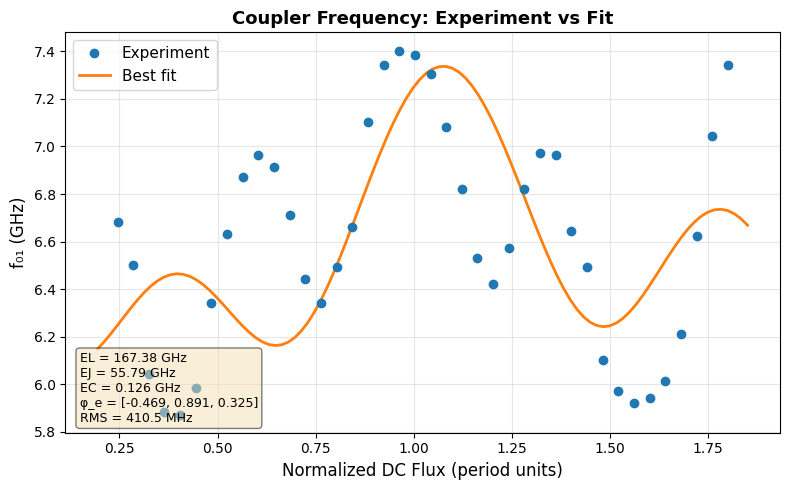

In [30]:
# =====================================================================
# Plot fit result: re-run simulation at higher resolution with optimal params
# =====================================================================

# Higher-resolution simulation for a smooth plot
N_plot = 100  # number of flux sweep points for plotting
phi_ext_plot = np.linspace(DC_x.min() - 0.05, DC_x.max() + 0.05, N_plot)
f01_plot = np.zeros(N_plot)

print("Computing fit curve at higher resolution...")
for i, phi_ext in enumerate(phi_ext_plot):
    phi_e_array = phi_e_opt + phi_ext
    result = full_analysis(
        phi_total_mag=2,
        N_opt=40,           # full resolution for final plot
        N_fine=1000,
        phi_e_array=phi_e_array,
        N_potential=N_potential,
        EL=EL_opt, EJ=EJ_opt, EC=EC,
        n_levels=3,
        order=5, n_starts=1, seed=0,
        options={"maxiter": 100, "gtol": 1e-7}
    )
    f01_plot[i] = result['E_GHz'][1] - result['E_GHz'][0]
    if (i + 1) % 25 == 0:
        print(f"  {i+1}/{N_plot} done")

print("Done.")

# ---- Plot experimental data vs best-fit simulation ----
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(DC_x, f01_data_GHz, 'o', markersize=6, color='C0',
        label='Experiment', zorder=3)
ax.plot(phi_ext_plot, f01_plot, '-', linewidth=2, color='C1',
        label='Best fit', zorder=2)

ax.set_xlabel('Normalized DC Flux (period units)', fontsize=12)
ax.set_ylabel('f₀₁ (GHz)', fontsize=12)
ax.set_title('Coupler Frequency: Experiment vs Fit', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Annotate with fit parameters
textstr = (f"EL = {EL_opt:.2f} GHz\n"
           f"EJ = {EJ_opt:.2f} GHz\n"
           f"EC = {EC} GHz\n"
           f"φ_e = [{phi_e_opt[0]:.3f}, {phi_e_opt[1]:.3f}, {phi_e_opt[2]:.3f}]\n"
           f"RMS = {np.sqrt(opt_result.fun / len(DC_x)) * 1e3:.1f} MHz")
ax.text(0.02, 0.02, textstr, transform=ax.transAxes, fontsize=9,
        verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# Data L2

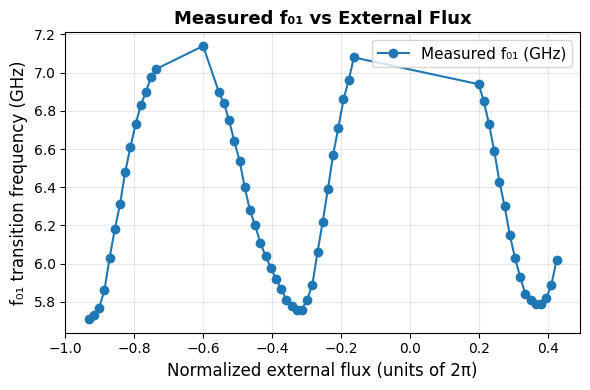

58 58


In [55]:
flux_npi = 1.75
period = 2.81+3.09

DC_x = np.array([-1.0, -0.9556, -0.9111, -0.8667, -0.8222, -0.7778, -0.7333, -0.6889, -0.6444, -0.6, \
                 -0.5556, -0.5111, -0.4667, -0.4222, -0.0222, 0.1111, 0.1556, 0.2, 0.2444, 0.2889, \
                 0.3333, 0.3778, 0.4222, 0.4667, 0.5111, 0.5556, 0.6, 0.6444, 0.6889, 0.7333, 0.7778, \
                 0.8222, 0.8667, 0.9111, 0.9556, 1.0, 1.0444, 1.0889, 1.1333, 1.1778, 1.222, 1.2667, \
                 2.333, 2.3778, 2.4222, 2.4667, 2.5111, 2.5556, 2.6, 2.6444, 2.6889, 2.7333, 2.7778, \
                 2.8222, 2.8667, 2.9111, 2.9556, 3.0])

DC_x = (DC_x-flux_npi)/period*2

peak_point = np.array([1.55e9, 1.57e9, 1.61e9, 1.7e9, 1.87e9, 2.02e9, 2.15e9, 2.32e9, 2.45e9, 2.57e9, \
                       2.67e9, 1.37e9*2, 1.41e9*2, 1.43e9*2, 1.49e9*2, 1.37e9*2, 2.68e9, 2.59e9, 2.48e9, 2.38e9, \
                       2.24e9, 2.12e9, 2.04e9, 1.95e9, 1.88e9, 1.82e9, 1.76e9, 1.71e9, 1.65e9, 1.62e9, 1.6e9, \
                       1.6e9, 1.65e9, 1.73e9, 1.9e9, 2.06e9, 2.23e9, 2.41e9, 2.55e9, 2.7e9, 1.4e9*2, 1.46e9*2, \
                       1.39e9*2, 2.69e9, 2.57e9, 2.43e9, 2.27e9, 2.14e9, 1.99e9, 1.87e9, 1.77e9, 1.68e9, 1.65e9, \
                       1.63e9, 1.63e9, 1.66e9, 1.73e9, 1.86e9])+4159.767997395101e+6

# Convert to GHz (same units as simulation output)
f01_data_GHz = peak_point / 1e9

plt.figure(figsize=(6, 4))
plt.plot(DC_x, f01_data_GHz, 'o-', label='Measured f₀₁ (GHz)', color='C0')
plt.xlabel('Normalized external flux (units of 2π)', fontsize=12)
plt.ylabel('f₀₁ transition frequency (GHz)', fontsize=12)
plt.title('Measured f₀₁ vs External Flux', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(len(DC_x), len(f01_data_GHz))

In [56]:
flux_npi = 1.75
period = 2.81+3.09

DC_x = np.array([-1.0, -0.9556, -0.9111, -0.8667, -0.8222, -0.7778, -0.7333, -0.6889, -0.6444, -0.6, \
                 -0.5556, -0.5111, -0.4667, -0.4222, -0.0222, 0.1111, 0.1556, 0.2, 0.2444, 0.2889, \
                 0.3333, 0.3778, 0.4222, 0.4667, 0.5111, 0.5556, 0.6, 0.6444, 0.6889, 0.7333, 0.7778, \
                 0.8222, 0.8667, 0.9111, 0.9556, 1.0, 1.0444, 1.0889, 1.1333, 1.1778, 1.222, 1.2667, \
                 2.333, 2.3778, 2.4222, 2.4667, 2.5111, 2.5556, 2.6, 2.6444, 2.6889, 2.7333, 2.7778, \
                 2.8222, 2.8667, 2.9111, 2.9556, 3.0])

DC_x = (DC_x-flux_npi)/period*2

peak_point = np.array([1.55e9, 1.57e9, 1.61e9, 1.7e9, 1.87e9, 2.02e9, 2.15e9, 2.32e9, 2.45e9, 2.57e9, \
                       2.67e9, 1.37e9*2, 1.41e9*2, 1.43e9*2, 1.49e9*2, 1.37e9*2, 2.68e9, 2.59e9, 2.48e9, 2.38e9, \
                       2.24e9, 2.12e9, 2.04e9, 1.95e9, 1.88e9, 1.82e9, 1.76e9, 1.71e9, 1.65e9, 1.62e9, 1.6e9, \
                       1.6e9, 1.65e9, 1.73e9, 1.9e9, 2.06e9, 2.23e9, 2.41e9, 2.55e9, 2.7e9, 1.4e9*2, 1.46e9*2, \
                       1.39e9*2, 2.69e9, 2.57e9, 2.43e9, 2.27e9, 2.14e9, 1.99e9, 1.87e9, 1.77e9, 1.68e9, 1.65e9, \
                       1.63e9, 1.63e9, 1.66e9, 1.73e9, 1.86e9])+4159.767997395101e+6

# Convert to GHz (same units as simulation output)
f01_data_GHz = peak_point / 1e9

# =====================================================================
# Fixed circuit parameters
# =====================================================================

N_potential  = 3       # number of nonlinear branches
EC           = 0.126   # charging energy (GHz), fixed
EL_EJ_ratio  = 3.0     # EL / EJ ratio, fixed

# =====================================================================
# Simulation settings (reduced resolution for speed during fitting)
# Increase N_opt_fit / N_fine_fit for better accuracy at cost of runtime.
# =====================================================================

N_opt_fit    = 40      # coarse grid for Born-Oppenheimer minimization
N_fine_fit   = 400     # fine grid for diagonalization
n_levels_fit = 2       # number of energy levels to compute

# =====================================================================
# Cost function: sum of squared residuals between simulation and data
# =====================================================================

points = 2 # use every 2nd point to speed up fitting; adjust as needed for accuracy/runtime tradeoff
DC_x = DC_x[::points]
f01_data_GHz = f01_data_GHz[::points]

eval_count = [0]       # mutable counter for progress printing

def cost_function(params):
    """
    params = [phi_e_initial[0], phi_e_initial[1], phi_e_initial[2], EL]
    Returns sum of squared residuals (GHz^2) between simulated and measured f01.
    """
    phi_e_init = np.array(params[:N_potential])   # per-branch flux offsets (Phi_0)
    EL = params[N_potential]                      # inductive energy (GHz)

    EJ = EL / EL_EJ_ratio                         # Josephson energy from fixed ratio

    f01_sweep = np.zeros(len(DC_x))
    for j, phi_ext in enumerate(DC_x):
        # Each branch sees its own offset + the global sweep flux
        phi_e_array = phi_e_init + phi_ext

        result = full_analysis(
            phi_total_mag=2,
            N_opt=N_opt_fit,
            N_fine=N_fine_fit,
            phi_e_array=phi_e_array,
            N_potential=N_potential,
            EL=EL, EJ=EJ, EC=EC,
            n_levels=n_levels_fit,
            order=5,
            n_starts=1,
            seed=0,
            options={"maxiter": 50, "gtol": 1e-6}
        )
        f01_sweep[j] = result['E_GHz'][1] - result['E_GHz'][0]

    # Least-squares residual
    residual = np.sum((f01_sweep - f01_data_GHz) ** 2)

    # Progress reporting
    eval_count[0] += 1
    if eval_count[0] % 5 == 0:
        rms_MHz = np.sqrt(residual / len(DC_x)) * 1e3
        print(f"  Eval {eval_count[0]:4d}:  residual = {residual:.4f} GHz²   "
              f"RMS = {rms_MHz:.1f} MHz   EL = {EL:.2f}   "
              f"phi_e = [{phi_e_init[0]:.3f}, {phi_e_init[1]:.3f}, {phi_e_init[2]:.3f}]")

    return residual

# =====================================================================
# Parameter bounds for global optimization
# =====================================================================

bounds = [
    (-1.0, 1.0),     # phi_e_initial[0]  (units of Phi_0)
    (-1.0, 1.0),     # phi_e_initial[1]
    (-1.0, 1.0),     # phi_e_initial[2]
    (30.0, 300.0),   # EL (GHz) — broad range around expected ~130 GHz
]

# =====================================================================
# Run differential evolution (global optimizer)
#
# popsize=15 → population of 15 × 4 = 60 individuals per generation
# polish=True → refines best solution with local L-BFGS-B at the end
# Typical runtime: tens of minutes to ~1 hour depending on machine.
# To speed up: reduce N_opt_fit, N_fine_fit, or popsize.
# =====================================================================

print("=" * 70)
print("Global least-squares fit: phi_e_initial (3 params) + EL (1 param)")
print(f"  Fixed: EC = {EC} GHz, EL/EJ = {EL_EJ_ratio}")
print(f"  Data points: {len(DC_x)}")
print(f"  Simulation grid: N_opt={N_opt_fit}, N_fine={N_fine_fit}, N_sweep={len(DC_x)}")
print("=" * 70)

eval_count[0] = 0
t_start = time.time()

opt_result = differential_evolution(
    cost_function,
    bounds,
    maxiter=20,             # max number of generations
    popsize=15,             # individuals per parameter dimension
    tol=1e-4,               # relative convergence tolerance
    mutation=(0.5, 1.0),    # differential weight (dithered for robustness)
    recombination=0.7,      # crossover probability
    seed=0,                 # reproducibility
    disp=True,              # print generation-level progress
    polish=True,            # local refinement after DE converges
)

t_elapsed = time.time() - t_start

# =====================================================================
# Extract and display optimized parameters
# =====================================================================

phi_e_opt = opt_result.x[:N_potential]
EL_opt    = opt_result.x[N_potential]
EJ_opt    = EL_opt / EL_EJ_ratio

print("\n" + "=" * 70)
print("OPTIMIZATION RESULTS")
print("=" * 70)
print(f"  phi_e_initial = [{phi_e_opt[0]:.6f}, {phi_e_opt[1]:.6f}, {phi_e_opt[2]:.6f}] Phi_0")
print(f"  EL = {EL_opt:.4f} GHz")
print(f"  EJ = {EJ_opt:.4f} GHz")
print(f"  EC = {EC} GHz (fixed)")
print(f"  EL/EJ = {EL_EJ_ratio} (fixed)")
print(f"  Residual = {opt_result.fun:.6f} GHz²")
print(f"  RMS error = {np.sqrt(opt_result.fun / len(DC_x)) * 1e3:.1f} MHz")
print(f"  Elapsed time = {t_elapsed:.1f} s ({t_elapsed/60:.1f} min)")
print(f"  Function evaluations = {opt_result.nfev}")
print(f"  Converged: {opt_result.success}  ({opt_result.message})")

Global least-squares fit: phi_e_initial (3 params) + EL (1 param)
  Fixed: EC = 0.126 GHz, EL/EJ = 3.0
  Data points: 29
  Simulation grid: N_opt=40, N_fine=400, N_sweep=29
  Eval    5:  residual = 49.4128 GHz²   RMS = 1305.3 MHz   EL = 157.78   phi_e = [0.257, -0.014, 0.820]
  Eval   10:  residual = 53.7383 GHz²   RMS = 1361.3 MHz   EL = 116.03   phi_e = [-0.281, 0.267, -0.375]
  Eval   15:  residual = 571.7794 GHz²   RMS = 4440.3 MHz   EL = 276.74   phi_e = [0.424, 0.690, 0.417]
  Eval   20:  residual = 247.2928 GHz²   RMS = 2920.2 MHz   EL = 38.51   phi_e = [-0.004, 0.179, -0.256]
  Eval   25:  residual = 10.2078 GHz²   RMS = 593.3 MHz   EL = 163.62   phi_e = [-0.495, 0.577, 0.203]
  Eval   30:  residual = 186.5797 GHz²   RMS = 2536.5 MHz   EL = 61.25   phi_e = [-0.749, -0.496, 0.490]
  Eval   35:  residual = 99.3478 GHz²   RMS = 1850.9 MHz   EL = 75.27   phi_e = [-0.534, 0.498, 0.460]
  Eval   40:  residual = 188.6927 GHz²   RMS = 2550.8 MHz   EL = 292.91   phi_e = [0.873, -0.454, 

# Plot data with fit

Computing fit curve at higher resolution...
  25/100 done
  50/100 done
  75/100 done
  100/100 done
Done.


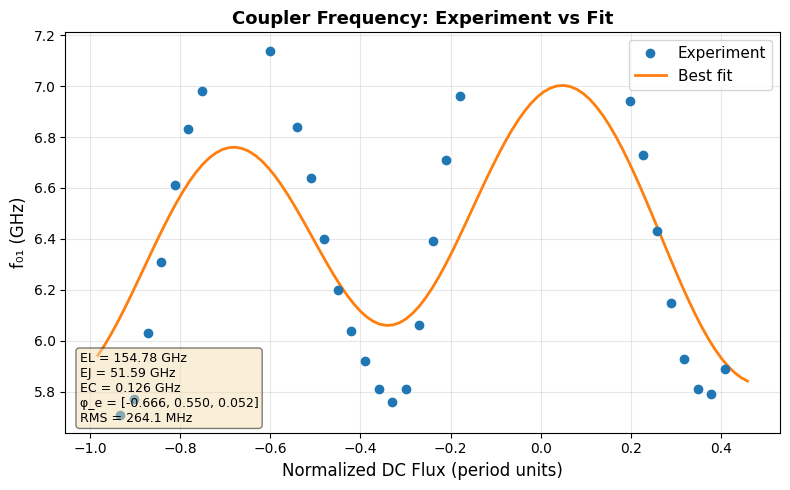

In [59]:
# =====================================================================
# Plot fit result: re-run simulation at higher resolution with optimal params
# =====================================================================

# Higher-resolution simulation for a smooth plot
N_plot = 100  # number of flux sweep points for plotting
phi_ext_plot = np.linspace(DC_x.min() - 0.05, DC_x.max() + 0.05, N_plot)
f01_plot = np.zeros(N_plot)

print("Computing fit curve at higher resolution...")
for i, phi_ext in enumerate(phi_ext_plot):
    phi_e_array = phi_e_opt + phi_ext
    result = full_analysis(
        phi_total_mag=2,
        N_opt=40,           # full resolution for final plot
        N_fine=1000,
        phi_e_array=phi_e_array,
        N_potential=N_potential,
        EL=EL_opt, EJ=EJ_opt, EC=EC,
        n_levels=3,
        order=5, n_starts=1, seed=0,
        options={"maxiter": 100, "gtol": 1e-7}
    )
    f01_plot[i] = result['E_GHz'][1] - result['E_GHz'][0]
    if (i + 1) % 25 == 0:
        print(f"  {i+1}/{N_plot} done")

print("Done.")

# ---- Plot experimental data vs best-fit simulation ----
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(DC_x, f01_data_GHz, 'o', markersize=6, color='C0',
        label='Experiment', zorder=3)
ax.plot(phi_ext_plot, f01_plot, '-', linewidth=2, color='C1',
        label='Best fit', zorder=2)

ax.set_xlabel('Normalized DC Flux (period units)', fontsize=12)
ax.set_ylabel('f₀₁ (GHz)', fontsize=12)
ax.set_title('Coupler Frequency: Experiment vs Fit', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Annotate with fit parameters
textstr = (f"EL = {EL_opt:.2f} GHz\n"
           f"EJ = {EJ_opt:.2f} GHz\n"
           f"EC = {EC} GHz\n"
           f"φ_e = [{phi_e_opt[0]:.3f}, {phi_e_opt[1]:.3f}, {phi_e_opt[2]:.3f}]\n"
           f"RMS = {np.sqrt(opt_result.fun / len(DC_x)) * 1e3:.1f} MHz")
ax.text(0.02, 0.02, textstr, transform=ax.transAxes, fontsize=9,
        verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# Classical optimization

In [16]:
flux_npi = 1.75
period = 2.81+3.09

DC_x = np.array([-1.0, -0.9556, -0.9111, -0.8667, -0.8222, -0.7778, -0.7333, -0.6889, -0.6444, -0.6, \
                 -0.5556, -0.5111, -0.4667, -0.4222, -0.0222, 0.1111, 0.1556, 0.2, 0.2444, 0.2889, \
                 0.3333, 0.3778, 0.4222, 0.4667, 0.5111, 0.5556, 0.6, 0.6444, 0.6889, 0.7333, 0.7778, \
                 0.8222, 0.8667, 0.9111, 0.9556, 1.0, 1.0444, 1.0889, 1.1333, 1.1778, 1.222, 1.2667, \
                 2.333, 2.3778, 2.4222, 2.4667, 2.5111, 2.5556, 2.6, 2.6444, 2.6889, 2.7333, 2.7778, \
                 2.8222, 2.8667, 2.9111, 2.9556, 3.0])

DC_x = (DC_x-flux_npi)/period*2

peak_point = np.array([1.55e9, 1.57e9, 1.61e9, 1.7e9, 1.87e9, 2.02e9, 2.15e9, 2.32e9, 2.45e9, 2.57e9, \
                       2.67e9, 1.37e9*2, 1.41e9*2, 1.43e9*2, 1.49e9*2, 1.37e9*2, 2.68e9, 2.59e9, 2.48e9, 2.38e9, \
                       2.24e9, 2.12e9, 2.04e9, 1.95e9, 1.88e9, 1.82e9, 1.76e9, 1.71e9, 1.65e9, 1.62e9, 1.6e9, \
                       1.6e9, 1.65e9, 1.73e9, 1.9e9, 2.06e9, 2.23e9, 2.41e9, 2.55e9, 2.7e9, 1.4e9*2, 1.46e9*2, \
                       1.39e9*2, 2.69e9, 2.57e9, 2.43e9, 2.27e9, 2.14e9, 1.99e9, 1.87e9, 1.77e9, 1.68e9, 1.65e9, \
                       1.63e9, 1.63e9, 1.66e9, 1.73e9, 1.86e9])+4159.767997395101e+6

# Convert to GHz (same units as simulation output)
f01_data_GHz = peak_point / 1e9

# =====================================================================
# Fixed circuit parameters
# =====================================================================

N_potential  = 3       # number of nonlinear branches
EC           = 0.126   # charging energy (GHz), fixed
# EL_EJ_ratio  = 3.0     # EL / EJ ratio, fixed

points = 1 # use every 2nd point to speed up fitting; adjust as needed for accuracy/runtime tradeoff
DC_x = DC_x[::points]
f01_data_GHz = f01_data_GHz[::points]

eval_count = [0]       # mutable counter for progress printing

def cost_function(params):
    """
    params = [phi_e_initial[0], phi_e_initial[1], phi_e_initial[2], EL]
    Returns sum of squared residuals (GHz^2) between simulated and measured f01.
    """
    phi_e_init = np.array(params[:N_potential])   # per-branch flux offsets (Phi_0)
    EL = params[N_potential]                      # inductive energy (GHz)
    EL_EJ_ratio = params[N_potential + 1]        # EL/EJ ratio
    EJ = EL / EL_EJ_ratio                         # Josephson energy from variable ratio

    f01_sweep = classical_freq_function_of_flux(phi_e_initial=phi_e_init, phi_e_apply=DC_x, EL=EL, EJ=EJ, EC=EC)

    # Least-squares residual
    residual = np.sum((f01_sweep - f01_data_GHz) ** 2)

    # Progress reporting
    eval_count[0] += 1
    if eval_count[0] % 10000 == 0:
        rms_MHz = np.sqrt(residual / len(DC_x)) * 1e3
        print(f"  Eval {eval_count[0]:4d}:  residual = {residual:.4f} GHz²   "
              f"RMS = {rms_MHz:.1f} MHz   EL = {EL:.2f}   "
              f"phi_e = [{phi_e_init[0]:.3f}, {phi_e_init[1]:.3f}, {phi_e_init[2]:.3f}]")

    return residual

# =====================================================================
# Parameter bounds for global optimization
# =====================================================================

bounds = [
    (-1.0, 1.0),     # phi_e_initial[0]  (units of Phi_0)
    (-1.0, 1.0),     # phi_e_initial[1]
    (-1.0, 1.0),     # phi_e_initial[2]
    (30.0, 300.0),   # EL (GHz) — broad range around expected ~130 GHz
    (2, 15),    # EL/EJ ratio — broad range around expected ~3
]

# =====================================================================
# Run differential evolution (global optimizer)
#
# popsize=15 → population of 15 × 4 = 60 individuals per generation
# polish=True → refines best solution with local L-BFGS-B at the end
# Typical runtime: tens of minutes to ~1 hour depending on machine.
# To speed up: reduce N_opt_fit, N_fine_fit, or popsize.
# =====================================================================

print("=" * 70)
print("Global least-squares fit: phi_e_initial (3 params) + EL (1 param) + EL/EJ (1 param)")
print(f"  Fixed: EC = {EC} GHz, EL/EJ = variable")
print(f"  Data points: {len(DC_x)}")
print("=" * 70)

eval_count[0] = 0
t_start = time.time()

opt_result = differential_evolution(
    cost_function,
    bounds,
    maxiter=1000,             # max number of generations
    popsize=100,             # individuals per parameter dimension
    tol=1e-8,               # relative convergence tolerance
    mutation=(0.5, 1.0),    # differential weight (dithered for robustness)
    recombination=0.7,      # crossover probability
    seed=0,                 # reproducibility
    disp=True,              # print generation-level progress
    polish=True,            # local refinement after DE converges
)

t_elapsed = time.time() - t_start

# =====================================================================
# Extract and display optimized parameters
# =====================================================================

phi_e_opt = opt_result.x[:N_potential]
EL_opt    = opt_result.x[N_potential]
EL_EJ_ratio_opt = opt_result.x[N_potential + 1]
EJ_opt    = EL_opt / EL_EJ_ratio_opt

print("\n" + "=" * 70)
print("OPTIMIZATION RESULTS")
print("=" * 70)
print(f"  phi_e_initial = [{phi_e_opt[0]:.6f}, {phi_e_opt[1]:.6f}, {phi_e_opt[2]:.6f}] Phi_0")
print(f"  EL = {EL_opt:.4f} GHz")
print(f"  EJ = {EJ_opt:.4f} GHz")
print(f"  EC = {EC} GHz (fixed)")
print(f"  EL/EJ = {EL_EJ_ratio_opt:.4f} (variable)")
print(f"  Residual = {opt_result.fun:.6f} GHz²")
print(f"  RMS error = {np.sqrt(opt_result.fun / len(DC_x)) * 1e3:.1f} MHz")
print(f"  Elapsed time = {t_elapsed:.1f} s ({t_elapsed/60:.1f} min)")
print(f"  Function evaluations = {opt_result.nfev}")
print(f"  Converged: {opt_result.success}  ({opt_result.message})")

Global least-squares fit: phi_e_initial (3 params) + EL (1 param) + EL/EJ (1 param)
  Fixed: EC = 0.126 GHz, EL/EJ = variable
  Data points: 58
differential_evolution step 1: f(x)= 10.753614116506675
differential_evolution step 2: f(x)= 10.753614116506675
differential_evolution step 3: f(x)= 10.609788836447553
differential_evolution step 4: f(x)= 8.021386424855516
differential_evolution step 5: f(x)= 8.021386424855516
differential_evolution step 6: f(x)= 7.160525857813675
differential_evolution step 7: f(x)= 7.160525857813675
differential_evolution step 8: f(x)= 7.160525857813675
differential_evolution step 9: f(x)= 7.160525857813675
differential_evolution step 10: f(x)= 7.160525857813675
differential_evolution step 11: f(x)= 7.160525857813675
differential_evolution step 12: f(x)= 6.849829109141642
differential_evolution step 13: f(x)= 6.849829109141642
differential_evolution step 14: f(x)= 6.849829109141642
differential_evolution step 15: f(x)= 6.753559075631379
differential_evolution

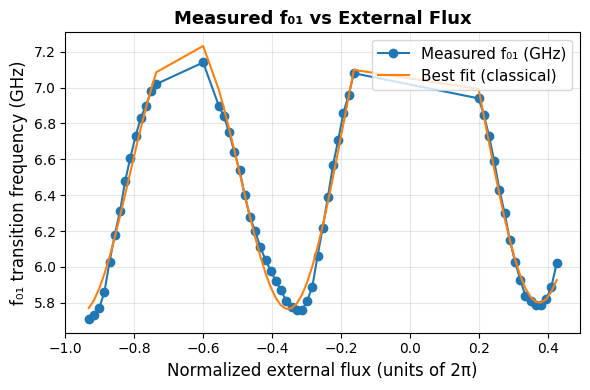

In [17]:
figure = plt.figure(figsize=(6, 4))
plt.plot(DC_x, f01_data_GHz, 'o-', label='Measured f₀₁ (GHz)', color='C0')
plt.plot(DC_x, classical_freq_function_of_flux(phi_e_initial=phi_e_opt, phi_e_apply=DC_x, EL=EL_opt, EJ=EJ_opt, EC=EC), '-', label='Best fit (classical)', color='C1')
plt.xlabel('Normalized external flux (units of 2π)', fontsize=12)
plt.ylabel('f₀₁ transition frequency (GHz)', fontsize=12)
plt.title('Measured f₀₁ vs External Flux', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

Computing fit curve at higher resolution...
  25/100 done
  50/100 done
  75/100 done
  100/100 done
Done.


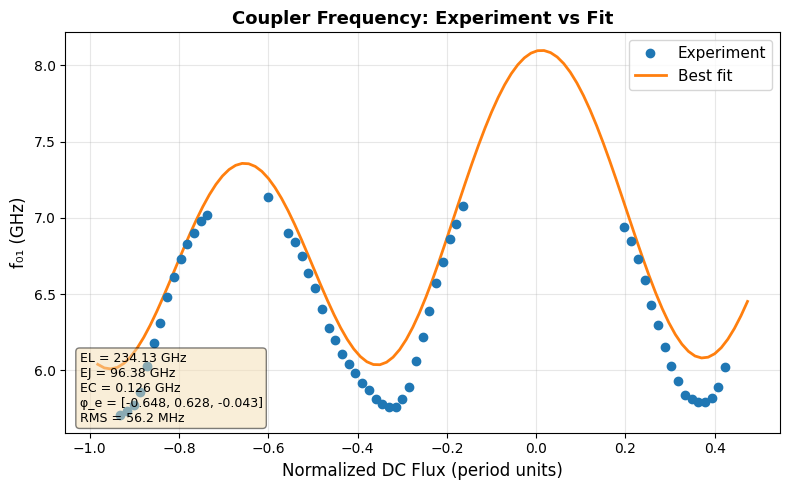

In [18]:
# =====================================================================
# Plot fit result: re-run simulation at higher resolution with optimal params
# =====================================================================

# Higher-resolution simulation for a smooth plot
N_plot = 100  # number of flux sweep points for plotting
phi_ext_plot = np.linspace(DC_x.min() - 0.05, DC_x.max() + 0.05, N_plot)
f01_plot = np.zeros(N_plot)

print("Computing fit curve at higher resolution...")
for i, phi_ext in enumerate(phi_ext_plot):
    phi_e_array = phi_e_opt + phi_ext
    result = full_analysis(
        phi_total_mag=2,
        N_opt=40,           # full resolution for final plot
        N_fine=1000,
        phi_e_array=phi_e_array,
        N_potential=N_potential,
        EL=EL_opt, EJ=EJ_opt, EC=EC,
        n_levels=3,
        order=5, n_starts=1, seed=0,
        options={"maxiter": 300, "gtol": 1e-7}
    )
    f01_plot[i] = result['E_GHz'][1] - result['E_GHz'][0]
    if (i + 1) % 25 == 0:
        print(f"  {i+1}/{N_plot} done")

print("Done.")

# ---- Plot experimental data vs best-fit simulation ----
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(DC_x, f01_data_GHz, 'o', markersize=6, color='C0',
        label='Experiment', zorder=3)
ax.plot(phi_ext_plot, f01_plot, '-', linewidth=2, color='C1',
        label='Best fit', zorder=2)

ax.set_xlabel('Normalized DC Flux (period units)', fontsize=12)
ax.set_ylabel('f₀₁ (GHz)', fontsize=12)
ax.set_title('Coupler Frequency: Experiment vs Fit', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Annotate with fit parameters
textstr = (f"EL = {EL_opt:.2f} GHz\n"
           f"EJ = {EJ_opt:.2f} GHz\n"
           f"EC = {EC} GHz\n"
           f"φ_e = [{phi_e_opt[0]:.3f}, {phi_e_opt[1]:.3f}, {phi_e_opt[2]:.3f}]\n"
           f"RMS = {np.sqrt(opt_result.fun / len(DC_x)) * 1e3:.1f} MHz")
ax.text(0.02, 0.02, textstr, transform=ax.transAxes, fontsize=9,
        verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()